# Programmes Data Check

## What this notebook does

This notebook checks the programme data. It looks for missing values, wrong IDs, bad dates, and broken links.

## Files used

- `Programmes.csv` has the programme data.
- `Organisations.csv` has the organisation data.
- `Branches.csv` has the branch data.
- `Programme_Services.csv` has the services for each programme.
- `Participations.csv` has the people in each programme.

There is only one programme. We can check this row, but we cannot find trends from one row.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid")

def find_raw_data_dir(start: Path = Path.cwd()) -> Path:
    for directory in (start, *start.parents):
        for candidate in (directory / "data" / "raw", directory / "data-analytics" / "data" / "raw"):
            if candidate.is_dir():
                return candidate
    raise FileNotFoundError("Could not find data-analytics/data/raw")

RAW_DATA_DIR = find_raw_data_dir()

## 1. Read the files

In [2]:
programmes = pd.read_csv(RAW_DATA_DIR / "Programmes.csv")
organisations = pd.read_csv(RAW_DATA_DIR / "Organisations.csv")
branches = pd.read_csv(RAW_DATA_DIR / "Branches.csv")
programme_services = pd.read_csv(RAW_DATA_DIR / "Programme_Services.csv")
participations = pd.read_csv(RAW_DATA_DIR / "Participations.csv")

pd.DataFrame({
    "file": ["Programmes", "Organisations", "Branches", "Programme Services", "Participations"],
    "rows": [len(programmes), len(organisations), len(branches), len(programme_services), len(participations)],
    "columns": [len(programmes.columns), len(organisations.columns), len(branches.columns), len(programme_services.columns), len(participations.columns)],
})

,file,rows,columns
0,Programmes,1,11
1,Organisations,1,10
2,Branches,2,6
3,Programme Services,6,5
4,Participations,28,9


## 2. Look at the programme data

In [3]:
programmes

,programme_id,organisation_id,branch_id,name,programme_type,start_date,end_date,venue,status,target_participants,created_at
0,PRG-001,ORG-001,BR-001,2026 Workforce Wellness Programme,screening,2026-06-18T00:00:00Z,2026-06-18T00:00:00Z,Metsi Operations Site - Wellness Hall,completed,28,2026-05-22T10:00:00Z


In [4]:
programme_profile = pd.DataFrame({
    "data_type": programmes.dtypes.astype(str),
    "missing_count": programmes.isna().sum(),
    "unique_values": programmes.nunique(dropna=False),
})
programme_profile

,data_type,missing_count,unique_values
programme_id,object,0,1
organisation_id,object,0,1
branch_id,object,0,1
name,object,0,1
programme_type,object,0,1
start_date,object,0,1
end_date,object,0,1
venue,object,0,1
status,object,0,1
target_participants,int64,0,1


In [5]:
required_columns = [
    "programme_id", "organisation_id", "branch_id", "name",
    "programme_type", "start_date", "end_date", "venue",
    "status", "target_participants", "created_at",
]
assert set(required_columns).issubset(programmes.columns)
assert programmes[required_columns].notna().all().all()
print("All needed fields are present. No values are missing.")

All needed fields are present. No values are missing.


## 3. Check IDs and text

In [6]:
id_checks = pd.Series({
    "missing_programme_ids": programmes["programme_id"].isna().sum(),
    "duplicate_programme_ids": programmes["programme_id"].duplicated().sum(),
    "wrong_programme_id_format": (~programmes["programme_id"].str.match(r"^PRG-[0-9]{3}$", na=False)).sum(),
    "wrong_organisation_id_format": (~programmes["organisation_id"].str.match(r"^ORG-[0-9]{3}$", na=False)).sum(),
    "wrong_branch_id_format": (~programmes["branch_id"].str.match(r"^BR-[0-9]{3}$", na=False)).sum(),
})
id_checks.to_frame("count")

,count
missing_programme_ids,0
duplicate_programme_ids,0
wrong_programme_id_format,0
wrong_organisation_id_format,0
wrong_branch_id_format,0


In [7]:
text_columns = ["programme_id", "organisation_id", "branch_id", "name", "programme_type", "venue", "status"]
space_checks = pd.Series({
    column: programmes[column].ne(programmes[column].str.strip()).sum()
    for column in text_columns
})
space_checks.to_frame("rows_with_extra_spaces")

,rows_with_extra_spaces
programme_id,0
organisation_id,0
branch_id,0
name,0
programme_type,0
venue,0
status,0


In [8]:
assert programmes["programme_id"].is_unique
assert programmes["programme_id"].str.match(r"^PRG-[0-9]{3}$", na=False).all()
assert programmes["organisation_id"].str.match(r"^ORG-[0-9]{3}$", na=False).all()
assert programmes["branch_id"].str.match(r"^BR-[0-9]{3}$", na=False).all()
assert space_checks.eq(0).all()
print("The IDs are correct. The text has no extra spaces.")

The IDs are correct. The text has no extra spaces.


## 4. Check the dates and target

In [9]:
date_columns = ["start_date", "end_date", "created_at"]
programme_dates = programmes.copy()
for column in date_columns:
    programme_dates[column] = pd.to_datetime(programme_dates[column], utc=True, errors="coerce")

date_checks = pd.Series({
    "bad_start_dates": programme_dates["start_date"].isna().sum(),
    "bad_end_dates": programme_dates["end_date"].isna().sum(),
    "bad_created_dates": programme_dates["created_at"].isna().sum(),
    "end_before_start": (programme_dates["end_date"] < programme_dates["start_date"]).sum(),
    "created_after_start": (programme_dates["created_at"] > programme_dates["start_date"]).sum(),
    "zero_or_negative_targets": (programme_dates["target_participants"] <= 0).sum(),
})
date_checks.to_frame("count")

,count
bad_start_dates,0
bad_end_dates,0
bad_created_dates,0
end_before_start,0
created_after_start,0
zero_or_negative_targets,0


In [10]:
assert date_checks.eq(0).all()
print("The dates are valid. The end date is not before the start date. The target is above zero.")

The dates are valid. The end date is not before the start date. The target is above zero.


## 5. Check links to the organisation and branch

In [11]:
unknown_organisation_ids = sorted(set(programmes["organisation_id"]) - set(organisations["organisation_id"]))
unknown_branch_ids = sorted(set(programmes["branch_id"]) - set(branches["branch_id"]))
branch_check = programmes.merge(
    branches[["branch_id", "organisation_id"]].rename(columns={"organisation_id": "branch_organisation_id"}),
    on="branch_id", how="left", validate="many_to_one",
)
wrong_branch_organisation = branch_check["organisation_id"].ne(branch_check["branch_organisation_id"]).sum()
pd.Series({
    "unknown_organisation_ids": len(unknown_organisation_ids),
    "unknown_branch_ids": len(unknown_branch_ids),
    "branches_linked_to_wrong_organisation": wrong_branch_organisation,
}).to_frame("count")

,count
unknown_organisation_ids,0
unknown_branch_ids,0
branches_linked_to_wrong_organisation,0


In [12]:
assert not unknown_organisation_ids
assert not unknown_branch_ids
assert wrong_branch_organisation == 0
print("The programme links to the right organisation and branch.")

The programme links to the right organisation and branch.


## 6. Check services and people

In [13]:
unknown_service_programmes = sorted(set(programme_services["programme_id"]) - set(programmes["programme_id"]))
unknown_participation_programmes = sorted(set(participations["programme_id"]) - set(programmes["programme_id"]))
services_per_programme = programme_services.groupby("programme_id").size().rename("service_count")
people_per_programme = participations.groupby("programme_id").size().rename("participant_count")
programme_summary = (
    programmes[["programme_id", "name", "target_participants"]]
    .join(services_per_programme, on="programme_id")
    .join(people_per_programme, on="programme_id")
    .fillna({"service_count": 0, "participant_count": 0})
)
programme_summary[["service_count", "participant_count"]] = programme_summary[["service_count", "participant_count"]].astype(int)
programme_summary["target_reached_percent"] = (programme_summary["participant_count"] / programme_summary["target_participants"] * 100).round(1)
programme_summary

,programme_id,name,target_participants,service_count,participant_count,target_reached_percent
0,PRG-001,2026 Workforce Wellness Programme,28,6,28,100.0


In [14]:
attendance = participations.groupby(["programme_id", "attendance_status"]).size().rename("count").reset_index()
attendance

,programme_id,attendance_status,count
0,PRG-001,absent,2
1,PRG-001,attended,24
2,PRG-001,registered,2


In [15]:
assert not unknown_service_programmes
assert not unknown_participation_programmes
assert programme_services["programme_service_id"].is_unique
assert participations["participation_id"].is_unique
assert (programme_summary["service_count"] > 0).all()
print("The service and people links are correct. Each programme has at least one service.")

The service and people links are correct. Each programme has at least one service.


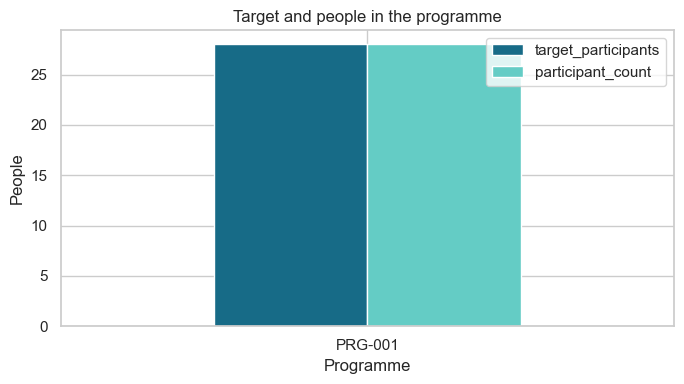

In [16]:
target_and_people = programme_summary.set_index("programme_id")[["target_participants", "participant_count"]]
ax = target_and_people.plot(kind="bar", color=["#176B87", "#64CCC5"], figsize=(7, 4))
ax.set(title="Target and people in the programme", xlabel="Programme", ylabel="People")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 7. What we found

The file has one programme. All fields have values. The programme ID is unique and has the right format. The dates are valid. The target is 28 people.

The programme links to the right organisation and branch. It has 6 services. It has 28 participant records, so the number of participant records is the same as the target.

Of the 28 people, 24 attended, 2 were absent, and 2 were still marked as registered. This means 85.7% of the participant records were marked as attended.

There is only one programme. We cannot compare programmes or find trends yet.

## For the next steps

- Keep the ID, date, and link checks.
- Check why 2 people are still marked as registered.
- Add more programme rows before looking for trends.
- Compare targets and attendance when there are more programmes.